In [ ]:
import zarr
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path1 = "/Volumes/data/Sasaki/MTsingleBeads/20241114/T2_4uM_mc03_beads_zarr/RDF.zarr"
path2 = "/Volumes/data/Sasaki/MTsingleBeads/20260107/RDF.zarr"
path3 = "/Volumes/data/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/RDF.zarr"
path4 = "/Volumes/data/Sasaki/MTsingleBeads/20260121/exp_crop1/RDF.zarr"
path5 = "/Volumes/data/Sasaki/MTsingleBeads/20260122/exp/RDF.zarr"
path6 = "/Volumes/data/Sasaki/MTsingleBeads/20260122/exp001/RDF.zarr"
path7 = "/Volumes/data/Sasaki/MTsingleBeads/20260122/exp002/RDF.zarr"

RDF1 = zarr.open_array(path1, mode = 'r')[:]
RDF2 = zarr.open_array(path2, mode = 'r')[:]
RDF3 = zarr.open_array(path3, mode = 'r')[:]
RDF4 = zarr.open_array(path4, mode = 'r')[:]
RDF5 = zarr.open_array(path5, mode = 'r')[:]
RDF6 = zarr.open_array(path6, mode = 'r')[:]
RDF7 = zarr.open_array(path7, mode = 'r')[:]

RDF=np.concat([RDF1, RDF2, RDF3, RDF4, RDF5, RDF6, RDF7])

scale = 0.11
plt.style.use('../libs/my_style.mplstyle')

[Text(0.5, 0, 'r [μm]'), Text(0, 0.5, 'RDF $g(r)$'), (0.0, 2.0)]

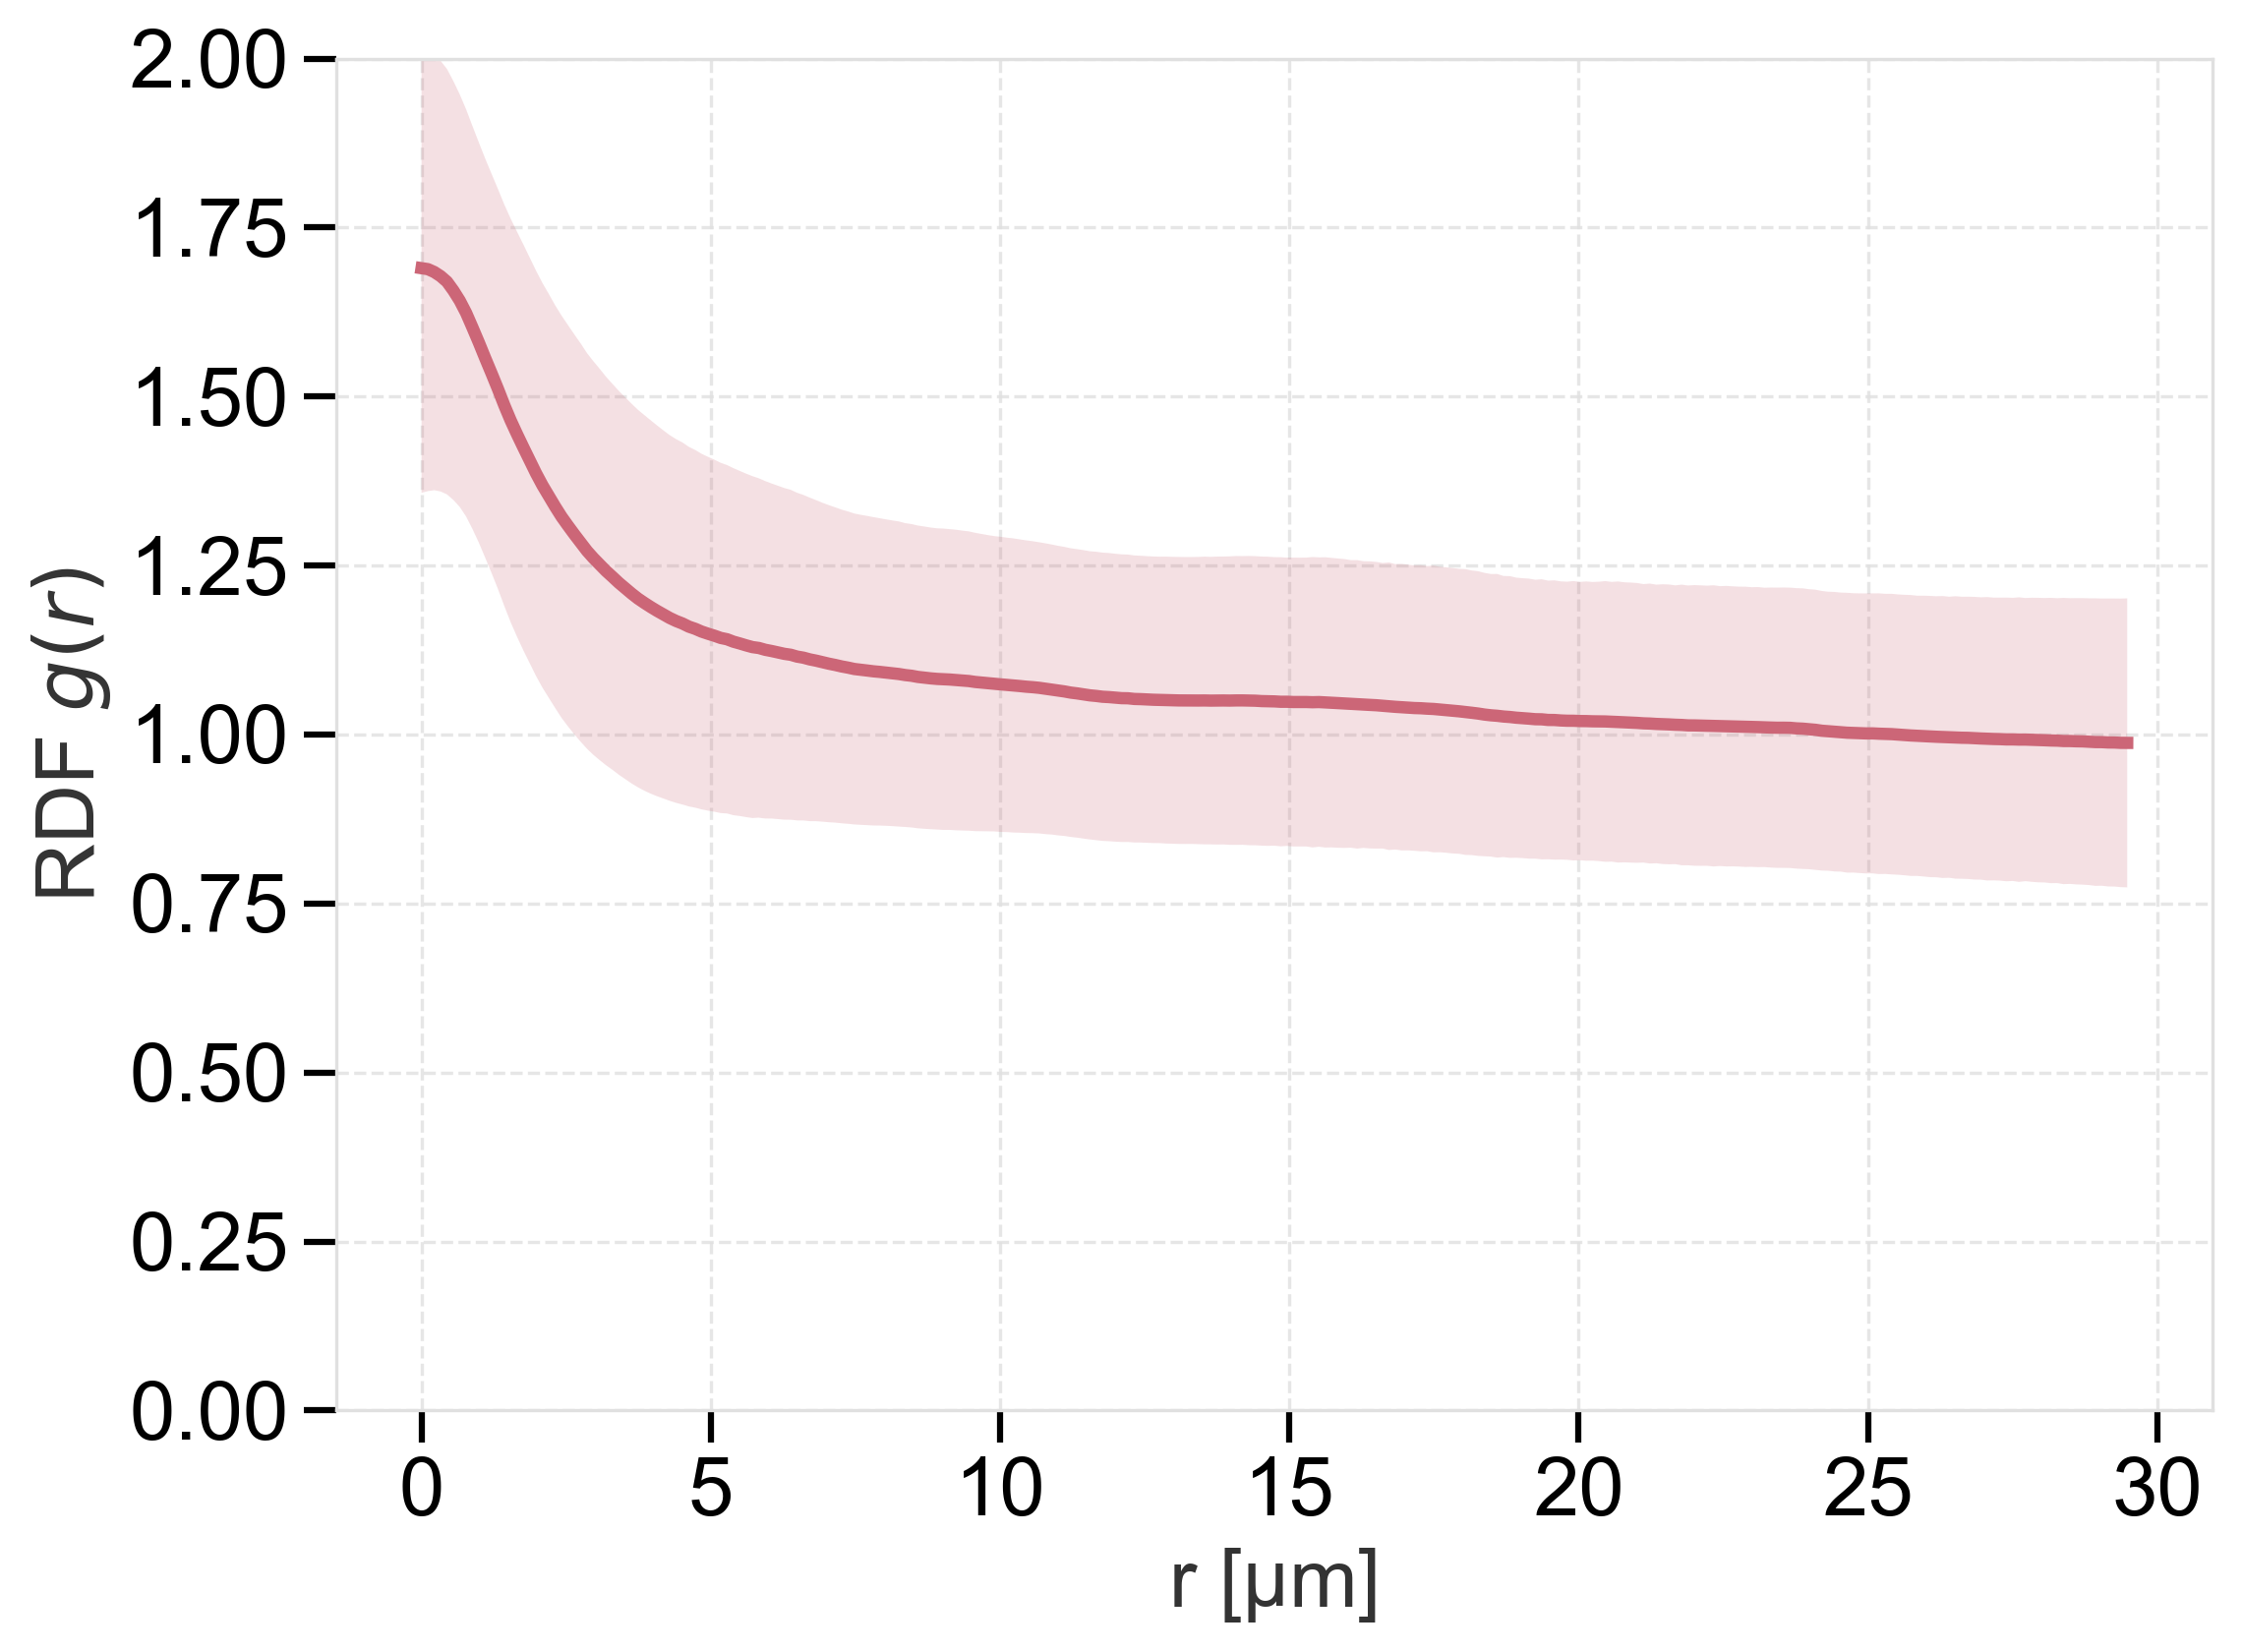

In [6]:
max_radius = RDF.shape[1]
radii_pixels = np.arange(max_radius)

fig, ax = plt.subplots()

"""for i in RDF:
    ax.plot(radii_pixels*scale, i, color="#333333", alpha = 0.005)"""

mean = np.mean(RDF, axis = 0)
std = np.std(RDF, axis = 0)

ax.plot(radii_pixels*scale, mean)
ax.fill_between(radii_pixels*scale, mean-std, mean+std, alpha=0.2)

ax.set(
    xlabel='r [\u03bcm]',
    ylabel='RDF $g(r)$',
    ylim=(0, 2)
)

[Text(0.5, 0, '$\\hat{r}$'),
 Text(0, 0.5, 'RDF $g(r)$'),
 (0.0, 10.0),
 (0.75, 2.0)]

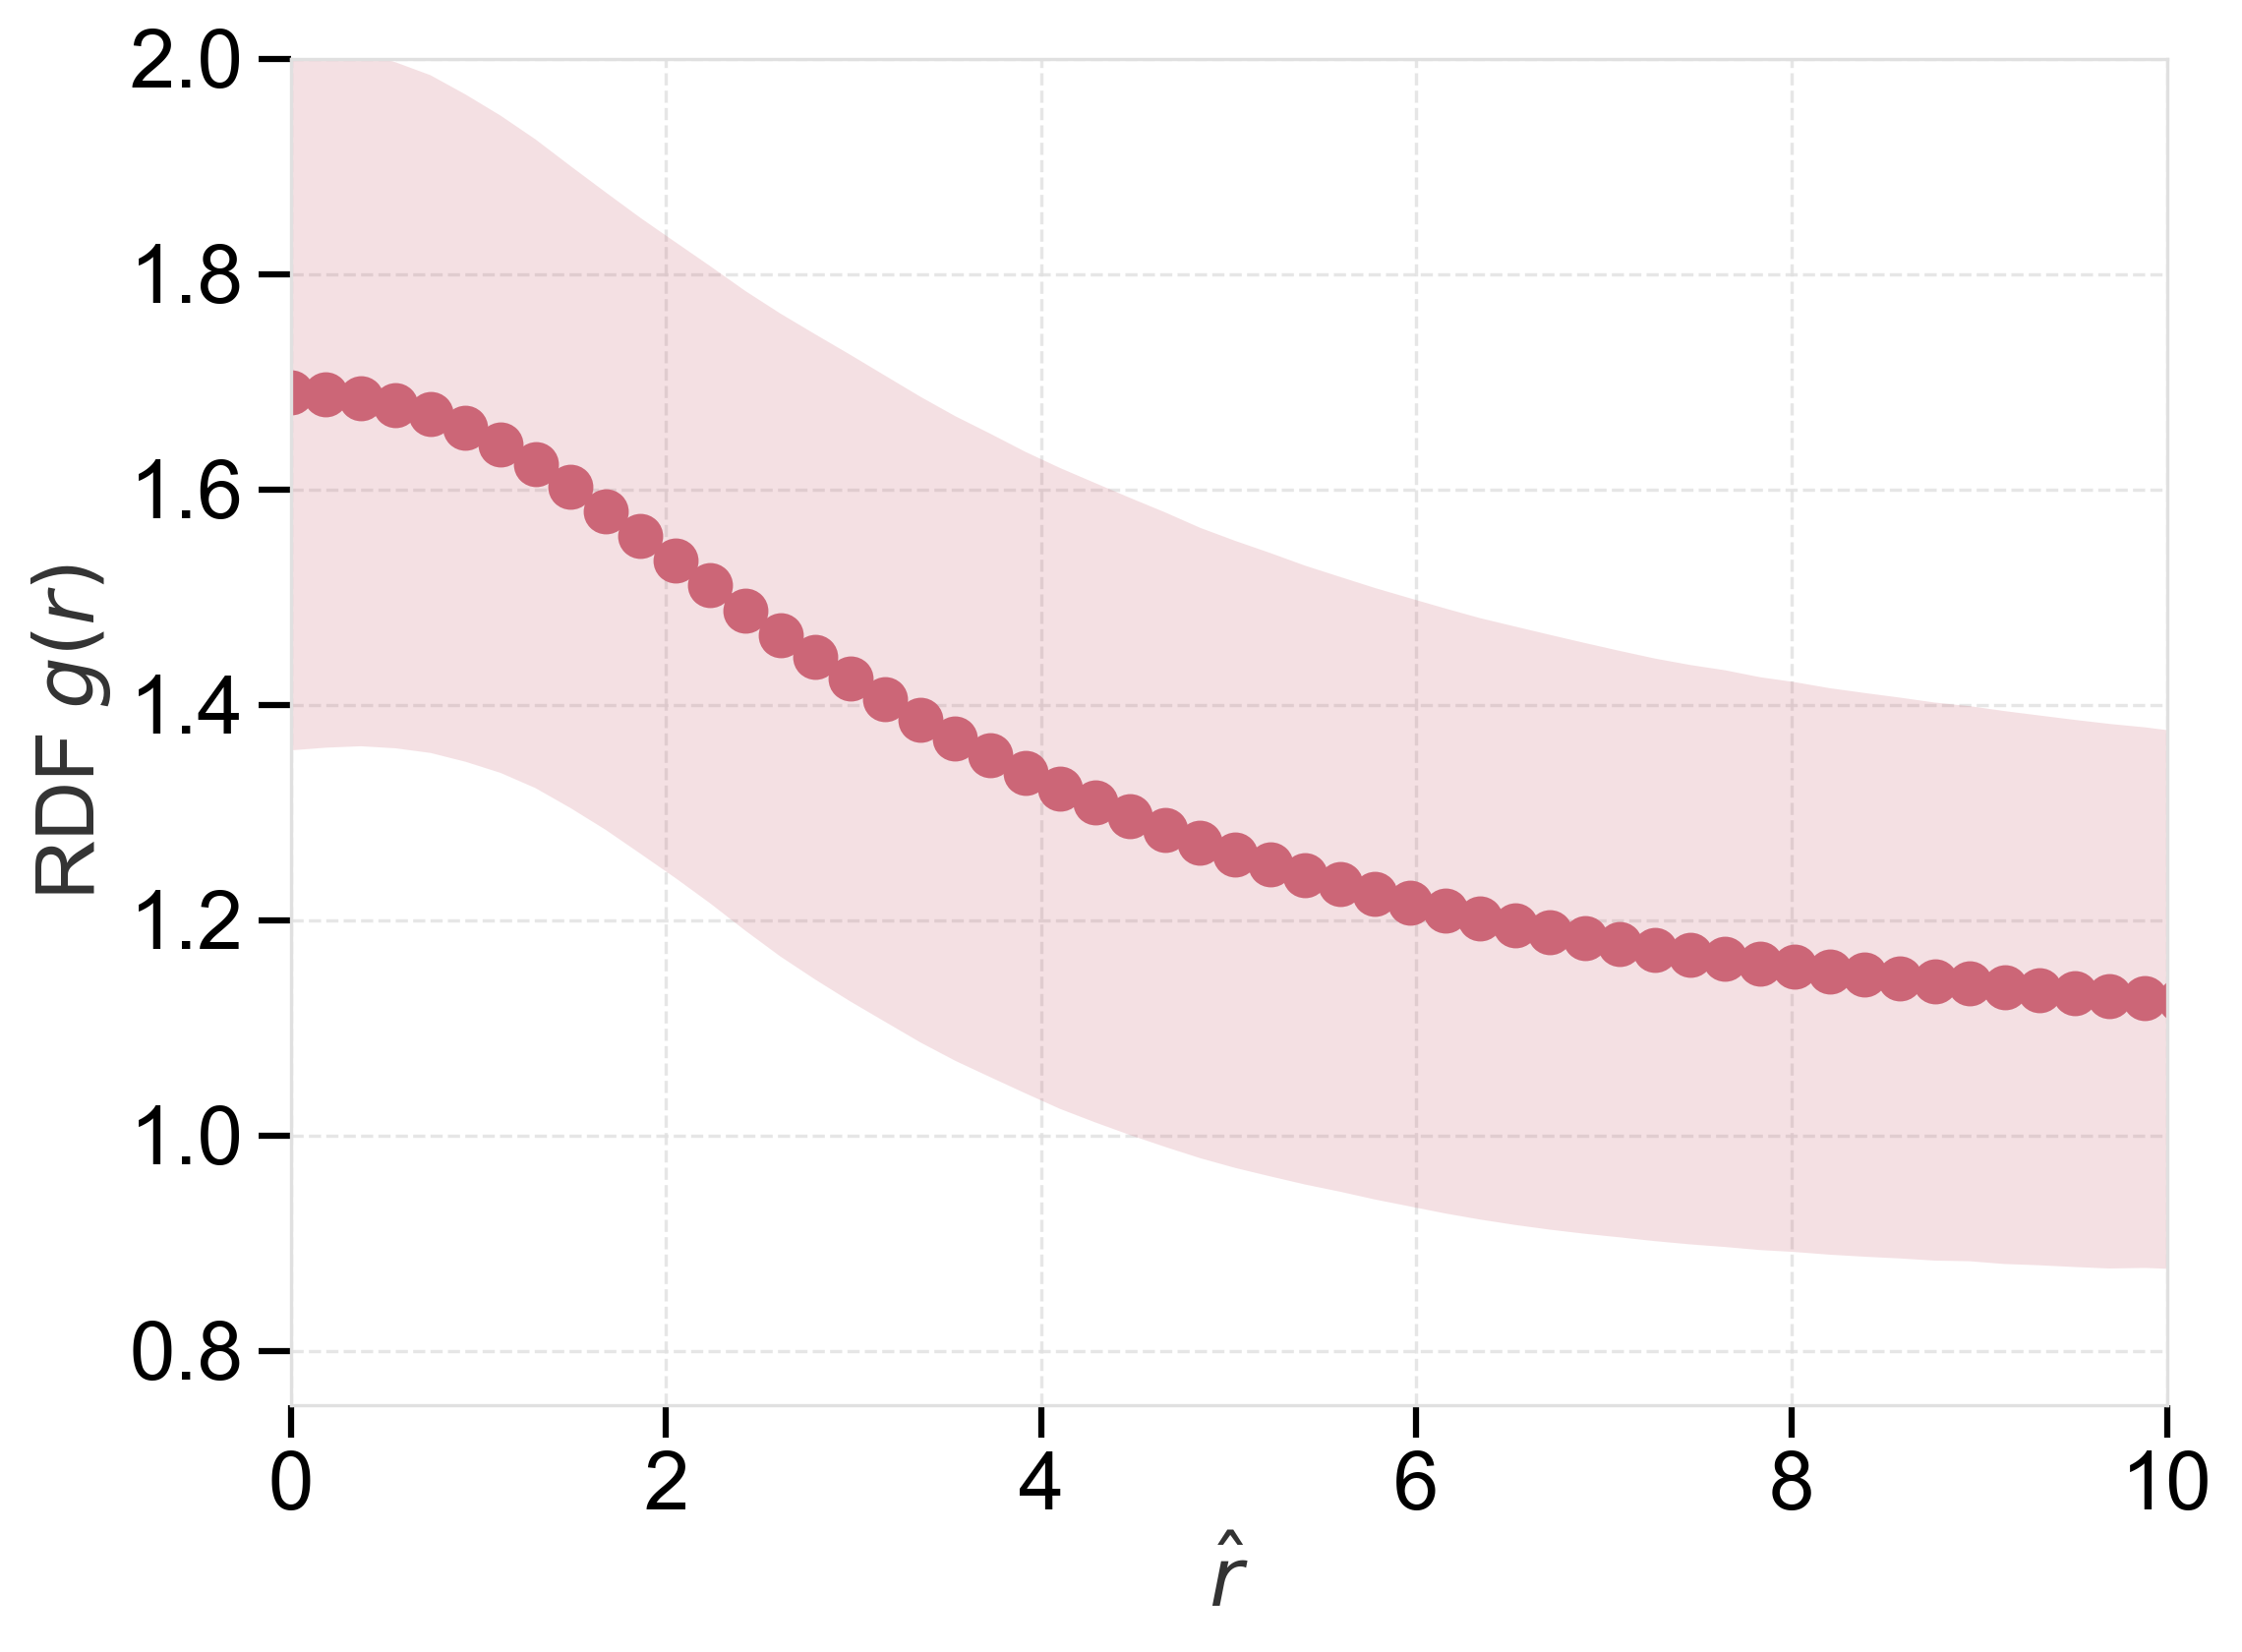

In [7]:
cargo_radius = 0.59

max_radius = RDF.shape[1]
radii_pixels = np.arange(max_radius)

fig, ax = plt.subplots()

"""for i in RDF:
    ax.plot(radii_pixels*scale, i, color="#333333", alpha = 0.005)"""

mean = np.mean(RDF, axis = 0)
std = np.std(RDF, axis = 0)

ax.plot(radii_pixels*scale/cargo_radius, mean, marker='o')
ax.fill_between(radii_pixels*scale/cargo_radius, mean-std, mean+std, alpha=0.2)

ax.set(
    xlabel='$\\hat{r}$',
    ylabel='RDF $g(r)$',
    xlim=(0,10),
    ylim=(0.75, 2)
)